In [3]:
# importing packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import scipy.io
import os
import numpy as np
from scipy.stats import pearsonr
import lime 
import lime.lime_tabular
import numpy as np 
import shap

In [4]:
# Define the base path (adjust path if needed)
base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "TEAM - Dataset", "data")

# Load only the first dataset
data = scipy.io.loadmat(os.path.join(base_dir, "1", "data.mat"))

# Extract variabl
X, y = data['X'], data['y']

print(f"Loaded successfully. Features shape: {X.shape}, Labels shape: {y.shape}")

Loaded successfully. Features shape: (198, 33), Labels shape: (198, 1)


### Trained the model

In [5]:
# Create the training and testing sets explicitly 
X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size = 0.2, random_state = 42)
# initialise the model 
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
# fit the model 
RF_model.fit(X_train, y_train)
# corss validate on the 80% training data
RF_crossval_score = cross_val_score(RF_model, X_train, y_train.ravel(), cv = 5)
RF_crossval_score

array([0.8125    , 0.78125   , 0.71875   , 0.80645161, 0.77419355])

In [6]:
y_pred_proba_original = RF_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y,y_pred_proba_original)
print(f"AUC score on orginal instances: {auc_score:.4f}")

AUC score on orginal instances: 0.9679


### SHAP

In [7]:
print(X_test.shape)
print(X_train.shape)

(40, 33)
(158, 33)


In [11]:
# create an object tha can explain the model 
explainer = shap.Explainer(RF_model, shap.maskers.Independent(X, max_samples=X.shape[0]))

In [28]:
# calculat shap values = computes the contribution of each feature to the models's predictions 
# RF_shap = explainer(X_train)
# RF_shap = explainer(X_train)
# for classifier shap_values is a list 

# suppary plot for values impact 
# shap.summary_plot(shap_values[:, :, 1], X_train)
RF_shap = explainer(X, check_additivity=False)


In [29]:
RF_shap.shape

(198, 33, 2)

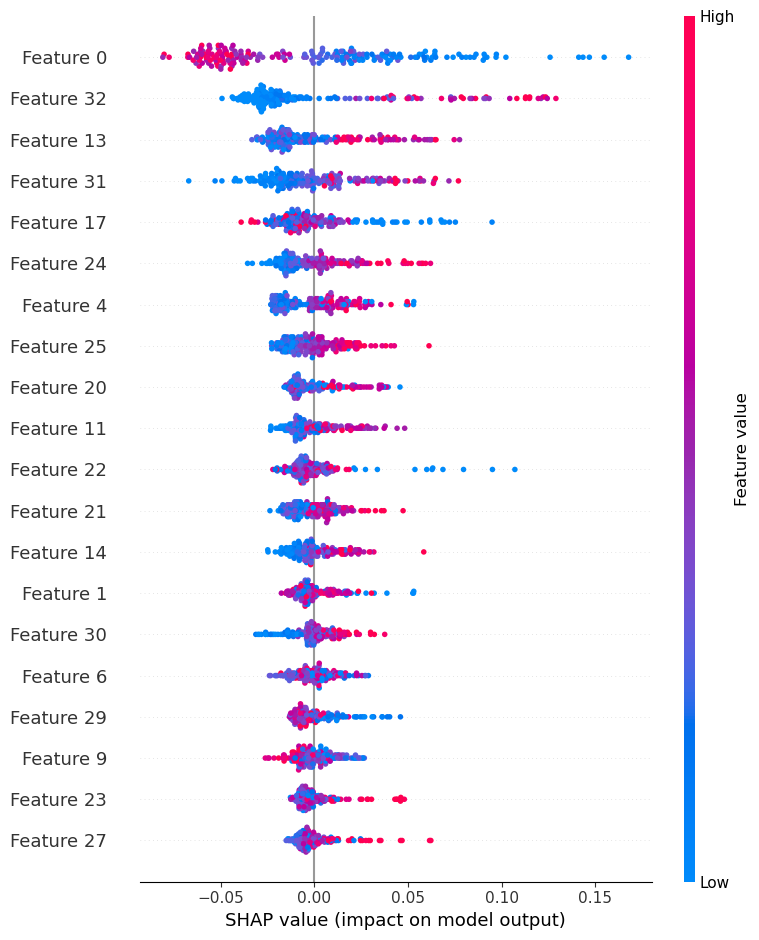

In [30]:
shap.summary_plot(RF_shap[:, :, 1], X)

### LIME

In [31]:
# Run this cell first!
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    feature_names=[f"f{i}" for i in range(X.shape[1])], 
    class_names=['Class 0', 'Class 1'], 
    mode='classification'
)


In [26]:
# Create a mapping of feature names (e.g., 'f0') to indices (e.g., 0)
feature_to_idx = {f"f{i}": i for i in range(X.shape[1])}
RF_LIME = np.zeros((len(X), X.shape[1]))

# Loop through all 198 instances
print("Generating LIME values...")
for i in range(len(X)):
    exp = explainer_lime.explain_instance(X[i], RF_model.predict_proba)
    
    # exp.as_list() returns tuples like ('f0 > 0.50', 0.12)
    for description, importance in exp.as_list(label=1):
        # Find which feature name exists in the description
        for feat_name, idx in feature_to_idx.items():
            if feat_name in description:
                RF_LIME[i, idx] = importance
                break 

print("LIME matrix shape:", RF_LIME.shape)


Generating LIME values...
LIME matrix shape: (198, 33)


In [27]:
RF_LIME

array([[ 0.03218744, -0.01118087, -0.01045493, ...,  0.        ,
         0.        ,  0.        ],
       [-0.04234986, -0.01484066,  0.01572808, ...,  0.        ,
         0.        ,  0.        ],
       [-0.0629597 , -0.01535119,  0.01380876, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.07317678, -0.0119665 , -0.01163685, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07143004, -0.01576019,  0.01521258, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07411079, -0.01166274, -0.01003515, ...,  0.        ,
         0.        ,  0.        ]])

### Correlation

In [33]:
print(type(RF_shap))
print( type(RF_LIME))

<class 'shap._explanation.Explanation'>
<class 'numpy.ndarray'>


In [36]:
import numpy as np
from scipy.stats import pearsonr

# 1. Ensure both are extracted as 2D (samples, features)
# Based on your previous cell, you already have:
# shap_matrix.shape -> (198, 33)
# lime_matrix.shape -> (198, 33)

# 2. Flatten both matrices to 1D
# .flatten() converts the (198, 33) matrix into a 1D array of 6,534 elements
shap_flat = shap_matrix.flatten()
lime_flat = lime_matrix.flatten()

# 3. Calculate the correlation
corr, p_value = pearsonr(shap_flat, lime_flat)

print(f"Correlation between SHAP and LIME: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation between SHAP and LIME: 0.4212
P-value: 2.2337e-279


In [38]:
# Assuming shap_matrix and lime_matrix are both (198, 33)
sample_correlations = []

for i in range(shap_matrix.shape[0]):
    # Calculate correlation for this specific row
    # We use np.corrcoef to get the correlation between two vectors
    corr = np.corrcoef(shap_matrix[i], lime_matrix[i])[0, 1]
    sample_correlations.append(corr)

# Convert to numpy array for easy plotting
sample_correlations = np.array(sample_correlations)

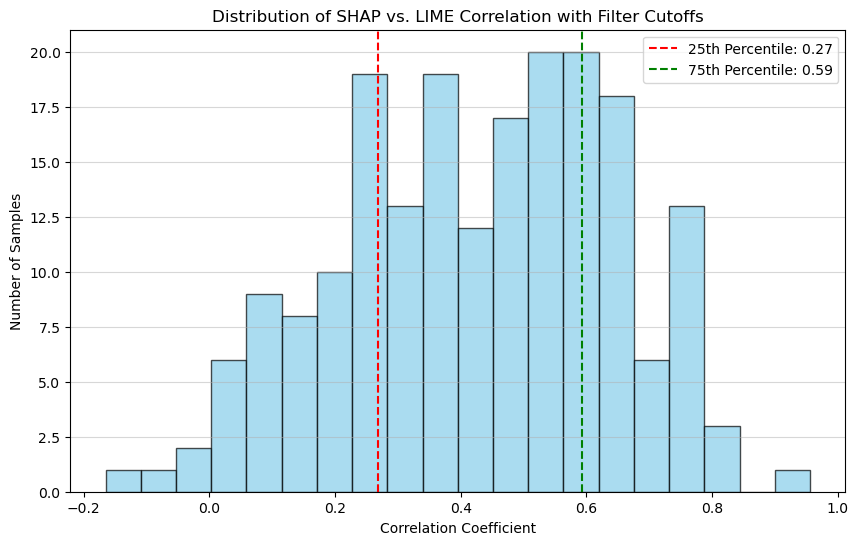

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the 25th and 75th percentiles
q25 = np.percentile(sample_correlations, 25)
q75 = np.percentile(sample_correlations, 75)

plt.figure(figsize=(10, 6))
plt.hist(sample_correlations, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical dotted lines
plt.axvline(q25, color='red', linestyle='--', label=f'25th Percentile: {q25:.2f}')
plt.axvline(q75, color='green', linestyle='--', label=f'75th Percentile: {q75:.2f}')

plt.title('Distribution of SHAP vs. LIME Correlation with Filter Cutoffs')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Number of Samples')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

### Subsetting the top 75%

In [73]:
# NumPy supports boolean masking directly
mask_top = (sample_correlations >= q25)
X_filtered_top = X[mask_top]


print(f"Original dataset size: {X.shape[0]}")
print(f"Filtered dataset size: {X_filtered_top.shape[0]}")

Original dataset size: 198
Filtered dataset size: 148


In [74]:
y_pred_proba_filtered = RF_model.predict_proba(X_filtered_top)[:, 1]

In [75]:
y_filtered_top = y[mask]

In [76]:
auc_filtered = roc_auc_score(y_filtered_top, y_pred_proba_filtered)

print(f"AUC score on filtered instances: {auc_filtered:.4f}")


AUC score on filtered instances: 0.5980


### Subsetting the Bottom 75%

In [77]:
mask_bottom =(sample_correlations <= q75)
X_filtered_bottom = X[mask_bottom]
print(f"Original dataset size: {X.shape[0]}")
print(f"Filtered dataset size: {X_filtered.shape[0]}")

Original dataset size: 198
Filtered dataset size: 148


In [78]:
y_filtered_bottom = y[mask]

In [79]:
y_pred_proba_filtered = RF_model.predict_proba(X_filtered_bottom)[:, 1]

In [81]:
auc_filtered = roc_auc_score(y_filtered_bottom, y_pred_proba_filtered)

print(f"AUC score on filtered instances: {auc_filtered:.4f}")

AUC score on filtered instances: 0.9913


### AUC on all 3 cases 

AUC on the orginal full set = 0.9679

AUC on the top 75%( meaning the worst performing 25% are filtered out ) = 0.9913

AUC on the bottom 75% ( Meaning the top performing 25% are filtered out) = 0.5980

### correilation on all 4 cases 

Corr RF_lime vs RF_shap Done 
Corr LR_lime Vs LR_shap Done 

Next 
Corr RF_LIME vs  LR_LIME 
Corr RF_Shap Vs LR_shap
